# OWMTL Respiratory Sound Diagnosis — Kick-Off Notebook
Member: Barshon Basak · Backbone Engineering Pillar
**Supervisor:** Dr. Riasat Khan  
**Target Venue:** Biomedical Signal Processing and Control (Elsevier, Q1, IF ~4.9)

---

This notebook fulfils the five supervisor kick-off requirements:
1. All preprocessing techniques on ICBHI 2017
2. Pre-trained DL models (ResNet-50 + EfficientNet-B2, with AST as stretch goal)
3. Accuracy, Precision, Recall, F1, Confusion Matrix, Model Size, # Params, Training Time
4. Training & Validation Loss and Accuracy vs. Epoch plots for every model
5. Data augmentation + re-evaluation with the same metrics and plots

**Task:** Sound-event classification — Normal / Crackle / Wheeze / Both (6 898 cycles, ICBHI 2017)  
**Hardware:** Google Colab GPU — set *Runtime → Change runtime type → GPU (T4 recommended)*


---
## 0. Dataset Setup (Google Colab)

**Two options to get the ICBHI 2017 dataset into Colab:**

### Option A — Kaggle API download (recommended, fully automatic)
1. Download your `kaggle.json` API token from https://www.kaggle.com/settings → *API → Create New Token*.
2. Run the **“0b. Kaggle API Download”** code cell below — it will prompt you to upload `kaggle.json`,
   then download & unzip the dataset automatically into `/content/`.

The dataset structure required:
```
respiratory-sound-database/
  Respiratory_Sound_Database/
    audio_and_txt_files/     ← .wav + .txt pairs (one .txt per recording with cycle annotations)
    patient_diagnosis.csv    ← patient-level disease labels
    demographic_info.txt     ← patient age, sex, adult BMI, child weight/height
```


In [3]:
# ── 0b. Kaggle API Download (Option A — recommended) ─────────────────────────
import os
from google.colab import files

KAGGLE_JSON = '/root/.kaggle/kaggle.json'
if not os.path.exists(KAGGLE_JSON):
    print("Upload your kaggle.json token (from kaggle.com → Settings → API):")
    uploaded = files.upload()                        # select kaggle.json from disk
    os.makedirs('/root/.kaggle', exist_ok=True)
    token_bytes = list(uploaded.values())[0]
    with open(KAGGLE_JSON, 'wb') as fh:
        fh.write(token_bytes)
    os.chmod(KAGGLE_JSON, 0o600)
    print("✅ kaggle.json saved.")
else:
    print("kaggle.json already present — skipping upload.")

DATASET_DIR = '/content/respiratory-sound-database'
if not os.path.exists(DATASET_DIR):
    os.system('pip install -q kaggle')
    os.system(
        'kaggle datasets download -d vbookshelf/respiratory-sound-database '
        '-p /content --unzip'
    )
    print("✅ Dataset downloaded and unzipped to /content/")
else:
    print("Dataset already present at", DATASET_DIR)


Upload your kaggle.json token (from kaggle.com → Settings → API):


Saving kaggle.json to kaggle.json
✅ kaggle.json saved.
✅ Dataset downloaded and unzipped to /content/


In [4]:
# ── Installs (run once; comment out after first run to save time) ──
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "librosa", "soundfile", "audiomentations",
                "scikit-learn", "matplotlib", "seaborn",
                "torchinfo", "tqdm", "pandas", "numpy",
                "opencv-python-headless"], check=True)
print("✅ Packages ready")


✅ Packages ready


In [5]:
import os, time, glob, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

import librosa
import soundfile as sf
from scipy.signal import butter, sosfilt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as tv_models
from torchvision.models import (
    resnet50,  ResNet50_Weights,
    efficientnet_b2, EfficientNet_B2_Weights,
)
from torchinfo import summary
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)
from sklearn.utils.class_weight import compute_class_weight

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")


Device : cuda
PyTorch: 2.11.0+cu128


---
## 1. Configuration & Paths

In [6]:
BASE = Path(
    "/content/Respiratory_Sound_Database/Respiratory_Sound_Database"
)
AUDIO_DIR = BASE / "audio_and_txt_files"
DIAG_CSV  = BASE / "patient_diagnosis.csv"
DEMO_TXT  = BASE / "demographic_info.txt"   # space-separated .txt (NOT a csv)
# Load later (if demographics needed) with:
#   demo_df = pd.read_csv(DEMO_TXT, sep=r"\s+", header=None,
#       names=["patient_id","age","sex","adult_bmi","child_weight","child_height"])

OUTPUT_DIR = Path("/content/owmtl_kickoff")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
NPY_DIR    = OUTPUT_DIR / "npy_cycles"
NPY_DIR.mkdir(exist_ok=True)

# ── Audio hyper-params ───────────────────────────────────────────────────────
SR          = 22050          # target sample-rate
CYCLE_SEC   = 5              # pad / truncate every cycle to 5 s
N_FFT       = 1024
HOP_LENGTH  = 512
N_MELS      = 128
N_MFCC      = 40
IMG_H       = 224            # resize target for CNN models (224×224)
IMG_W       = 224

LABEL_MAP   = {"Normal": 0, "Crackle": 1, "Wheeze": 2, "Both": 3}
IDX_TO_CLS  = {v: k for k, v in LABEL_MAP.items()}
NUM_CLASSES = 4

# ── Training hyper-params ────────────────────────────────────────────────────
EPOCHS     = 50
BATCH_SIZE = 32
LR         = 1e-4
WD         = 1e-4

print("Paths OK:", AUDIO_DIR.exists())

Paths OK: True


---
## 2. Preprocessing Pipeline (Supervisor Requirement #1)

All preprocessing is implemented as standalone functions so that `preprocess.py` can be exported for other group members.

In [7]:
# ── 2.1  Parse annotation .txt files ─────────────────────────────────────────
def parse_annotation(txt_path: Path) -> list[dict]:
    """
    Each line: start_time  end_time  crackle  wheeze
    Returns list of cycle dicts with label resolved to LABEL_MAP keys.
    """
    cycles = []
    with open(txt_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 4:
                continue
            t_start, t_end   = float(parts[0]), float(parts[1])
            has_crackle       = int(parts[2])
            has_wheeze        = int(parts[3])
            if   has_crackle and has_wheeze: label = "Both"
            elif has_crackle:                label = "Crackle"
            elif has_wheeze:                 label = "Wheeze"
            else:                            label = "Normal"
            cycles.append({"t_start": t_start, "t_end": t_end, "label": label})
    return cycles

def get_patient_id(filename: str) -> str:
    """Patient ID is the first numeric token in the filename."""
    return filename.split("_")[0]

# Load patient diagnosis labels
diag_df = pd.read_csv(DIAG_CSV, header=None, names=["patient_id", "diagnosis"])
diag_df["patient_id"] = diag_df["patient_id"].astype(str)
print(diag_df.head())
print("\nDisease distribution:")
print(diag_df["diagnosis"].value_counts())


  patient_id diagnosis
0        101      URTI
1        102   Healthy
2        103    Asthma
3        104      COPD
4        105      URTI

Disease distribution:
diagnosis
COPD              64
Healthy           26
URTI              14
Bronchiectasis     7
Bronchiolitis      6
Pneumonia          6
LRTI               2
Asthma             1
Name: count, dtype: int64


In [8]:
# ── 2.2  Noise reduction — Butterworth bandpass 100–2000 Hz ──────────────────
def bandpass_filter(signal: np.ndarray, sr: int,
                    low_hz: float = 100.0, high_hz: float = 2000.0,
                    order: int = 4) -> np.ndarray:
    """4th-order Butterworth bandpass filter. Respiratory sounds: 100–2000 Hz."""
    nyq = sr / 2.0
    sos = butter(order, [low_hz / nyq, high_hz / nyq], btype="band", output="sos")
    return sosfilt(sos, signal).astype(np.float32)


# ── 2.3  Amplitude normalisation ─────────────────────────────────────────────
def normalise(signal: np.ndarray) -> np.ndarray:
    peak = np.abs(signal).max()
    return signal / (peak + 1e-8)


In [9]:
# ── 2.4  Spectrogram representations ─────────────────────────────────────────
def to_mel_spectrogram(signal: np.ndarray, sr: int) -> np.ndarray:
    mel = librosa.feature.melspectrogram(
        y=signal, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    return mel.astype(np.float32)


def to_log_mel_spectrogram(signal: np.ndarray, sr: int) -> np.ndarray:
    mel  = to_mel_spectrogram(signal, sr)
    return librosa.power_to_db(mel, ref=np.max).astype(np.float32)


def to_mfcc(signal: np.ndarray, sr: int) -> np.ndarray:
    return librosa.feature.mfcc(
        y=signal, sr=sr, n_mfcc=N_MFCC,
        n_fft=N_FFT, hop_length=HOP_LENGTH).astype(np.float32)


# ── Resize spectrogram to (IMG_H, IMG_W) via bilinear interpolation ───────────
def resize_spec(spec: np.ndarray, h: int = IMG_H, w: int = IMG_W) -> np.ndarray:
    """spec shape: (freq, time) → returns (h, w) float32"""
    import cv2  # installed above via opencv-python-headless
    return cv2.resize(spec, (w, h), interpolation=cv2.INTER_LINEAR).astype(np.float32)


# ── Stack to 3-channel tensor for ImageNet-pretrained CNNs ───────────────────
def spec_to_3ch(spec: np.ndarray) -> np.ndarray:
    """(H, W) → (3, H, W) by duplicating the channel"""
    s = resize_spec(spec)
    return np.stack([s, s, s], axis=0)


In [10]:
# ── 2.5  Cycle extraction from a single recording ────────────────────────────
def extract_cycles(wav_path: Path, txt_path: Path) -> list[dict]:
    """
    Loads the recording, segments each annotated cycle,
    applies bandpass filter + normalisation, and returns:
      [{ 'signal': np.array(float32), 'label': str, 't_start': float, ... }, ...]
    """
    try:
        y, sr_orig = librosa.load(str(wav_path), sr=None, mono=True)
        y = librosa.resample(y, orig_sr=sr_orig, target_sr=SR)
    except Exception as e:
        print(f"  ⚠ Could not load {wav_path.name}: {e}")
        return []

    annotations = parse_annotation(txt_path)
    target_len  = int(CYCLE_SEC * SR)
    cycles      = []
    for ann in annotations:
        s = int(ann["t_start"] * SR)
        e = int(ann["t_end"]   * SR)
        segment = y[s:e]
        if len(segment) < SR * 0.3:          # skip < 300 ms fragments
            continue
        # Pad or truncate
        if len(segment) < target_len:
            segment = np.pad(segment, (0, target_len - len(segment)))
        else:
            segment = segment[:target_len]
        # Preprocess
        segment = bandpass_filter(segment, SR)
        segment = normalise(segment)
        cycles.append({**ann, "signal": segment.astype(np.float32)})
    return cycles


In [ ]:
# ── 2.6  Build dataset: extract all cycles, save .npy, build metadata CSV ────
wav_files  = sorted(AUDIO_DIR.glob("*.wav"))
print(f"Found {len(wav_files)} .wav files")

records = []
for wav_path in tqdm(wav_files, desc="Extracting cycles"):
    txt_path = wav_path.with_suffix(".txt")
    if not txt_path.exists():
        continue
    patient_id = get_patient_id(wav_path.stem)
    cycles     = extract_cycles(wav_path, txt_path)
    for i, c in enumerate(cycles):
        cycle_id = f"{wav_path.stem}_cycle{i:03d}"
        npy_path = NPY_DIR / f"{cycle_id}.npy"
        np.save(str(npy_path), c["signal"])
        records.append({
            "cycle_id":  cycle_id,
            "npy_path":  str(npy_path),
            "patient_id": patient_id,
            "label":     c["label"],
            "label_idx": LABEL_MAP[c["label"]],
            "t_start":   c["t_start"],
            "t_end":     c["t_end"],
        })

meta_df = pd.DataFrame(records)
print(f"\nTotal cycles extracted: {len(meta_df)}")
print(meta_df["label"].value_counts())


Found 920 .wav files


Extracting cycles:   0%|          | 0/920 [00:00<?, ?it/s]

In [ ]:
# ── 2.7  Patient-independent train/test split (official ICBHI 80/20) ─────────
# The official split file is 'ICBHI_challenge_train_test.txt' if included in the
# Kaggle dataset. If absent, we build it deterministically from patient IDs.

OFFICIAL_SPLIT = BASE / "ICBHI_challenge_train_test.txt"

if OFFICIAL_SPLIT.exists():
    split_df = pd.read_csv(OFFICIAL_SPLIT, sep="\t", header=None,
                           names=["filename", "split"])
    split_map = dict(zip(split_df["filename"].str.replace(".wav","",regex=False),
                         split_df["split"]))
    meta_df["recording_id"] = meta_df["cycle_id"].apply(
        lambda x: "_".join(x.split("_")[:-1]))
    meta_df["split"] = meta_df["recording_id"].map(split_map).fillna("train")
    print("Loaded official split.")
else:
    # Build patient-independent split: 80% train patients / 20% test patients
    rng         = np.random.default_rng(SEED)
    patients    = meta_df["patient_id"].unique()
    rng.shuffle(patients)
    n_test      = max(1, int(len(patients) * 0.20))
    test_pats   = set(patients[:n_test])
    meta_df["split"] = meta_df["patient_id"].apply(
        lambda p: "test" if p in test_pats else "train")
    print("Built patient-independent 80/20 split.")

# ── Sanity check: no patient overlap ─────────────────────────────────────────
train_pats = set(meta_df[meta_df["split"]=="train"]["patient_id"])
test_pats  = set(meta_df[meta_df["split"]=="test"]["patient_id"])
assert train_pats.isdisjoint(test_pats), "❌ Patient overlap in split!"
print(f"Train patients: {len(train_pats)} | Test patients: {len(test_pats)}")
print(meta_df["split"].value_counts())

# Save metadata
meta_df.to_csv(OUTPUT_DIR / "metadata.csv", index=False)
print("\n✅ Preprocessing complete — metadata.csv saved.")


In [ ]:
# ── 2.8  Visualise one sample from each class (all 3 representations) ────────
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
rep_names  = ["Mel Spectrogram", "Log-Mel Spectrogram", "MFCC (40 coeffs)"]
cmap       = "magma"

for row, cls in enumerate(["Normal", "Crackle", "Wheeze", "Both"]):
    sample = meta_df[meta_df["label"] == cls].iloc[0]
    y      = np.load(sample["npy_path"])

    specs = [to_mel_spectrogram(y, SR),
             to_log_mel_spectrogram(y, SR),
             to_mfcc(y, SR)]

    for col, (spec, name) in enumerate(zip(specs, rep_names)):
        ax = axes[row][col]
        img = ax.imshow(spec, aspect="auto", origin="lower",
                        cmap=cmap, interpolation="nearest")
        ax.set_title(f"{cls} — {name}", fontsize=9)
        ax.set_xlabel("Time frames"); ax.set_ylabel("Coeff / Mel bin")
        plt.colorbar(img, ax=ax, pad=0.02, fraction=0.04)

plt.suptitle("ICBHI 2017 — Spectral Representations per Class", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "spectrograms_preview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved spectrograms_preview.png")


In [ ]:
# ── 2.9  Class-imbalance stats + class weights for loss function ──────────────
train_labels = meta_df[meta_df["split"]=="train"]["label_idx"].values
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=train_labels)
CLASS_WEIGHTS = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)
print("Class weights:", dict(zip(IDX_TO_CLS.values(), CLASS_WEIGHTS.cpu().numpy().round(3))))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
counts  = meta_df[meta_df["split"]=="train"]["label"].value_counts()
ax.bar(counts.index, counts.values, color=["#4C9BE8","#E8784C","#4CE87C","#E84C9B"])
ax.set_title("ICBHI 2017 — Training Set Class Distribution")
ax.set_xlabel("Class"); ax.set_ylabel("Number of cycles")
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution.png", dpi=150)
plt.show()


In [ ]:
# ── 2.10  Compute per-channel mean/std on TRAINING set for normalisation ──────
# We do this on Log-Mel spectrograms since that's the primary model input.
print("Computing normalisation statistics on training set …")
sample_paths = meta_df[meta_df["split"]=="train"]["npy_path"].values
all_specs = []
for p in tqdm(sample_paths[:500], desc="Sampling 500 train cycles"):   # subset for speed
    y    = np.load(p)
    spec = resize_spec(to_log_mel_spectrogram(y, SR))               # (224,224)
    all_specs.append(spec)

all_specs = np.stack(all_specs)                  # (N, 224, 224)
SPEC_MEAN = float(all_specs.mean())
SPEC_STD  = float(all_specs.std())
print(f"Log-Mel  mean={SPEC_MEAN:.4f}  std={SPEC_STD:.4f}")
del all_specs  # free memory


---
## 3. PyTorch Dataset & DataLoader

In [ ]:
class ICBHIDataset(Dataset):
    """
    Returns a 3-channel (C, H, W) tensor of the Log-Mel spectrogram.
    augment=True applies waveform-level augmentation before spec conversion.
    """
    def __init__(self, df: pd.DataFrame, augment: bool = False):
        self.df      = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self): return len(self.df)

    # ── Waveform-level augmentations ─────────────────────────────────────────
    @staticmethod
    def _add_noise(y, snr_db=30):
        rms   = np.sqrt(np.mean(y**2)) + 1e-8
        noise = np.random.randn(len(y)) * (rms / (10 ** (snr_db/20)))
        return (y + noise).astype(np.float32)

    @staticmethod
    def _time_shift(y, max_frac=0.10):
        shift = int(np.random.uniform(-max_frac, max_frac) * len(y))
        return np.roll(y, shift).astype(np.float32)

    @staticmethod
    def _amplitude_scale(y, low=0.8, high=1.2):
        return (y * np.random.uniform(low, high)).astype(np.float32)

    @staticmethod
    def _pitch_shift(y, sr, steps_range=(-2, 2)):
        n_steps = np.random.uniform(*steps_range)
        return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps).astype(np.float32)

    @staticmethod
    def _time_stretch(y, rate_range=(0.9, 1.1)):
        rate       = np.random.uniform(*rate_range)
        stretched  = librosa.effects.time_stretch(y, rate=rate)
        target_len = len(y)
        if len(stretched) < target_len:
            stretched = np.pad(stretched, (0, target_len - len(stretched)))
        return stretched[:target_len].astype(np.float32)

    # ── Spectrogram-level augmentations (SpecAugment) ────────────────────────
    @staticmethod
    def _freq_mask(spec, F=15):
        f0 = np.random.randint(0, max(1, spec.shape[0] - F))
        spec = spec.copy(); spec[f0:f0+F, :] = spec.min()
        return spec

    @staticmethod
    def _time_mask(spec, T=30):
        t0 = np.random.randint(0, max(1, spec.shape[1] - T))
        spec = spec.copy(); spec[:, t0:t0+T] = spec.min()
        return spec

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        y   = np.load(row["npy_path"]).astype(np.float32)

        # ── Waveform augmentations (each 50% probability) ────────────────────
        if self.augment:
            if np.random.rand() < 0.5: y = self._add_noise(y)
            if np.random.rand() < 0.5: y = self._time_shift(y)
            if np.random.rand() < 0.5: y = self._amplitude_scale(y)
            if np.random.rand() < 0.5: y = self._pitch_shift(y, SR)
            if np.random.rand() < 0.5: y = self._time_stretch(y)
            y = normalise(y)

        # ── Spectrogram conversion ────────────────────────────────────────────
        spec = resize_spec(to_log_mel_spectrogram(y, SR))   # (224, 224)

        # ── Spectrogram augmentations ─────────────────────────────────────────
        if self.augment:
            if np.random.rand() < 0.5: spec = self._freq_mask(spec)
            if np.random.rand() < 0.5: spec = self._time_mask(spec)

        # ── Normalise + stack to 3-channel ────────────────────────────────────
        spec = (spec - SPEC_MEAN) / (SPEC_STD + 1e-8)
        tensor = torch.tensor(np.stack([spec, spec, spec], axis=0), dtype=torch.float32)
        label  = int(row["label_idx"])
        return tensor, label


In [ ]:
def make_loaders(augment_train: bool = False):
    train_df = meta_df[meta_df["split"] == "train"]
    test_df  = meta_df[meta_df["split"] == "test"]

    train_ds = ICBHIDataset(train_df, augment=augment_train)
    test_ds  = ICBHIDataset(test_df,  augment=False)

    # Weighted sampler to handle class imbalance in mini-batches
    sample_w = [class_weights_np[l] for l in train_df["label_idx"]]
    sampler  = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                              sampler=sampler, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)
    print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")
    return train_loader, test_loader


---
## 4. Pre-Trained Model Definitions (Supervisor Requirement #2)

In [ ]:
def build_resnet50():
    """ResNet-50 fine-tuned for 4-class sound-event classification."""
    m = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

def build_efficientnet_b2():
    """EfficientNet-B2 fine-tuned for 4-class sound-event classification."""
    m = efficientnet_b2(weights=EfficientNet_B2_Weights.IMAGENET1K_V1)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, NUM_CLASSES)
    return m

def freeze_backbone(model, model_name: str, unfreeze_top: bool = False):
    """
    Phase 1 (unfreeze_top=False): freeze all except the final classifier head.
    Phase 2 (unfreeze_top=True):  unfreeze everything for full fine-tuning.
    """
    if model_name == "resnet50":
        for name, p in model.named_parameters():
            if unfreeze_top:
                p.requires_grad = True
            else:
                p.requires_grad = "fc" in name or "layer4" in name
    elif model_name == "efficientnet_b2":
        for name, p in model.named_parameters():
            if unfreeze_top:
                p.requires_grad = True
            else:
                p.requires_grad = "classifier" in name or "features.7" in name
    return model

def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def model_size_mb(model, path="/tmp/_tmp_model.pt"):
    torch.save(model.state_dict(), path)
    mb = os.path.getsize(path) / 1e6
    os.remove(path)
    return round(mb, 2)


---
## 5. Training Loop & Metric Logging

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    t0 = time.time()
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X.size(0)
        correct      += (logits.argmax(1) == y).sum().item()
        total        += X.size(0)
    epoch_time = time.time() - t0
    return running_loss / total, correct / total, epoch_time


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, all_preds, all_labels = 0.0, [], []
    for X, y in loader:
        X, y   = X.to(DEVICE), y.to(DEVICE)
        logits = model(X)
        loss   = criterion(logits, y)
        running_loss += loss.item() * X.size(0)
        all_preds  += logits.argmax(1).cpu().tolist()
        all_labels += y.cpu().tolist()
    n = len(all_labels)
    return running_loss / n, accuracy_score(all_labels, all_preds), all_preds, all_labels


# ── Checkpoint helpers ────────────────────────────────────────────────────────

def _ckpt_path(ckpt_dir, epoch):
    return ckpt_dir / f'epoch_{epoch:03d}.pt'


def save_checkpoint(ckpt_dir, epoch, model, optimizer, scheduler,
                    history, best_f1, best_state, phase, total_train_time):
    """Save a full training state after every epoch. Keeps the 3 most recent."""
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    payload = {
        'epoch':            epoch,
        'model_state':      {k: v.cpu() for k, v in model.state_dict().items()},
        'optimizer_state':  optimizer.state_dict(),
        'scheduler_state':  scheduler.state_dict(),
        'history':          history,
        'best_f1':          best_f1,
        'best_state':       ({k: v.cpu() for k, v in best_state.items()}
                             if best_state else None),
        'phase':            phase,
        'total_train_time': total_train_time,
    }
    torch.save(payload, _ckpt_path(ckpt_dir, epoch))
    # Keep only the 3 latest checkpoints to save Drive space
    for old in sorted(ckpt_dir.glob('epoch_*.pt'))[:-3]:
        old.unlink(missing_ok=True)
    print(f'    [ckpt] Saved → {_ckpt_path(ckpt_dir, epoch).name}')


def load_latest_checkpoint(ckpt_dir):
    """Return the most recent epoch_*.pt payload, or None if none exist."""
    if not ckpt_dir.exists():
        return None
    ckpts = sorted(ckpt_dir.glob('epoch_*.pt'))
    if not ckpts:
        return None
    latest = ckpts[-1]
    print(f'  [resume] Loading checkpoint: {latest.name}')
    return torch.load(latest, map_location='cpu', weights_only=False)


def run_experiment(model_name, model, train_loader, test_loader,
                   tag='no_aug', checkpoint_dir=None):
    """
    Full training run for one model with per-epoch checkpointing and
    automatic resume on restart.

    Parameters
    ----------
    model_name     : 'resnet50' | 'efficientnet_b2'
    model          : freshly built nn.Module (weights overwritten if resuming)
    train_loader   : DataLoader for training split
    test_loader    : DataLoader for test split (never augmented)
    tag            : 'no_aug' | 'aug'
    checkpoint_dir : Path to save/load epoch checkpoints.
                     Defaults to OUTPUT_DIR/<model_name>_<tag>/checkpoints/
                     Pass a Drive path for persistence across Colab sessions.
    """
    print(f"\n{'='*60}")
    print(f'  MODEL: {model_name.upper()}  |  Setting: {tag}')
    print(f"{'='*60}")

    # ── Resolve checkpoint directory ──────────────────────────────────────────
    if checkpoint_dir is None:
        checkpoint_dir = OUTPUT_DIR / f'{model_name}_{tag}' / 'checkpoints'
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    print(f'  Checkpoint directory: {checkpoint_dir}')

    # ── Try to resume from an existing checkpoint ─────────────────────────────
    ckpt = load_latest_checkpoint(checkpoint_dir)

    WARMUP = 10
    model  = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

    # ── Phase 1 setup (warm-up): freeze backbone ──────────────────────────────
    model = freeze_backbone(model, model_name, unfreeze_top=False)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=WD)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[],
               'epoch_time_s': []}
    total_train_time = 0.0
    best_f1, best_state = 0.0, None
    start_epoch = 1
    phase = 1   # 1 = frozen warm-up, 2 = full fine-tune

    if ckpt is not None:
        # ── Restore full training state ───────────────────────────────────────
        restored_epoch = ckpt['epoch']
        phase          = ckpt['phase']

        # Rebuild optimizer/scheduler to match the saved phase
        if phase == 2 or restored_epoch >= WARMUP:
            model = freeze_backbone(model, model_name, unfreeze_top=True)
            optimizer = optim.AdamW(model.parameters(), lr=LR/5, weight_decay=WD)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=EPOCHS - WARMUP)

        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        scheduler.load_state_dict(ckpt['scheduler_state'])
        history          = ckpt['history']
        best_f1          = ckpt['best_f1']
        best_state       = ckpt['best_state']
        total_train_time = ckpt['total_train_time']
        start_epoch      = restored_epoch + 1

        print(f'  [resume] Resuming from epoch {restored_epoch} '
              f'→ starting at epoch {start_epoch}  (phase={phase})')
        if start_epoch > EPOCHS:
            print('  [resume] Training already completed — skipping training loop.')

    # ── Training loop ─────────────────────────────────────────────────────────
    for epoch in range(start_epoch, EPOCHS + 1):

        # Phase 2 kick-in: unfreeze full network after warm-up
        if epoch == WARMUP + 1 and phase == 1:
            phase = 2
            model = freeze_backbone(model, model_name, unfreeze_top=True)
            optimizer = optim.AdamW(model.parameters(), lr=LR/5, weight_decay=WD)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=EPOCHS - WARMUP)
            print(f'  [phase 2] Full fine-tune unlocked at epoch {epoch}.')

        tr_loss, tr_acc, ep_time = train_one_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc, preds, labels = evaluate(model, test_loader, criterion)
        scheduler.step()
        total_train_time += ep_time

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)
        history['epoch_time_s'].append(ep_time)

        ep_f1 = f1_score(labels, preds, average='weighted', zero_division=0)
        if ep_f1 > best_f1:
            best_f1    = ep_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Ep {epoch:3d}/{EPOCHS} | '
                  f'TrLoss={tr_loss:.4f} TrAcc={tr_acc:.4f} | '
                  f'VaLoss={va_loss:.4f} VaAcc={va_acc:.4f} | '
                  f'F1={ep_f1:.4f} | {ep_time:.1f}s')

        # ── Save checkpoint after EVERY epoch ─────────────────────────────────
        save_checkpoint(
            ckpt_dir         = checkpoint_dir,
            epoch            = epoch,
            model            = model,
            optimizer        = optimizer,
            scheduler        = scheduler,
            history          = history,
            best_f1          = best_f1,
            best_state       = best_state,
            phase            = phase,
            total_train_time = total_train_time,
        )

    # ── Final evaluation with best checkpoint ─────────────────────────────────
    model.load_state_dict(best_state)
    _, _, final_preds, final_labels = evaluate(model, test_loader, criterion)

    metrics = {
        'model':        model_name,
        'setting':      tag,
        'accuracy':     round(accuracy_score(final_labels, final_preds), 4),
        'precision_w':  round(precision_score(final_labels, final_preds, average='weighted', zero_division=0), 4),
        'precision_m':  round(precision_score(final_labels, final_preds, average='macro',    zero_division=0), 4),
        'recall_w':     round(recall_score(final_labels, final_preds, average='weighted',    zero_division=0), 4),
        'recall_m':     round(recall_score(final_labels, final_preds, average='macro',       zero_division=0), 4),
        'f1_weighted':  round(f1_score(final_labels, final_preds, average='weighted',        zero_division=0), 4),
        'f1_macro':     round(f1_score(final_labels, final_preds, average='macro',           zero_division=0), 4),
        'model_size_mb': model_size_mb(model),
        'total_params':  count_params(model)[0],
        'trainable_params': count_params(model)[1],
        'total_train_time_s': round(total_train_time, 1),
        'avg_epoch_time_s':   round(total_train_time / EPOCHS, 1),
    }

    save_dir = OUTPUT_DIR / f'{model_name}_{tag}'
    save_dir.mkdir(exist_ok=True)
    torch.save(best_state, save_dir / 'best_weights.pt')

    return model, history, metrics, final_preds, final_labels


---
## 6. Plotting Utilities (Supervisor Requirement #4)

In [20]:
def plot_training_curves(history: dict, model_name: str, tag: str, save_dir: Path):
    """Loss + Accuracy vs Epoch — saved as separate PNGs (supervisor requirement)."""
    epochs_x = range(1, len(history["train_loss"]) + 1)
    colors    = {"train": "#4C9BE8", "val": "#E8784C"}

    # Plot 1 — Loss
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(epochs_x, history["train_loss"], color=colors["train"],
            lw=2, label="Training Loss")
    ax.plot(epochs_x, history["val_loss"],   color=colors["val"],
            lw=2, linestyle="--", label="Validation Loss")
    ax.set_xlabel("Epoch", fontsize=12); ax.set_ylabel("Loss", fontsize=12)
    ax.set_title(f"{model_name.upper()} ({tag}) — Training & Validation Loss",
                 fontsize=13)
    ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(save_dir / "loss_curve.png", dpi=150)
    plt.show()

    # Plot 2 — Accuracy
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(epochs_x, [v*100 for v in history["train_acc"]],
            color=colors["train"], lw=2, label="Training Accuracy")
    ax.plot(epochs_x, [v*100 for v in history["val_acc"]],
            color=colors["val"],   lw=2, linestyle="--", label="Validation Accuracy")
    ax.set_xlabel("Epoch", fontsize=12); ax.set_ylabel("Accuracy (%)", fontsize=12)
    ax.set_title(f"{model_name.upper()} ({tag}) — Training & Validation Accuracy",
                 fontsize=13)
    ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(save_dir / "accuracy_curve.png", dpi=150)
    plt.show()
    print(f"  Saved curves → {save_dir}")


def plot_confusion_matrix(labels, preds, model_name: str, tag: str, save_dir: Path):
    cm   = confusion_matrix(labels, preds)
    cmn  = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, data, title_suffix in zip(
            axes, [cm, cmn], ["(Counts)", "(Row-Normalised)"]):
        sns.heatmap(data, annot=True,
                    fmt=".0f" if "Count" in title_suffix else ".2f",
                    cmap="Blues", ax=ax,
                    xticklabels=list(IDX_TO_CLS.values()),
                    yticklabels=list(IDX_TO_CLS.values()))
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_title(f"{model_name.upper()} ({tag}) Confusion Matrix {title_suffix}")

    fig.tight_layout()
    fig.savefig(save_dir / "confusion_matrix.png", dpi=150)
    plt.show()
    print(classification_report(labels, preds,
          target_names=list(IDX_TO_CLS.values()), zero_division=0))


---
## 7. Experiment 1 — ResNet-50 (No Augmentation)
*(Supervisor Requirements #2, #3, #4)*

Train batches: 175 | Test batches: 41
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]



  MODEL: RESNET50  |  Setting: no_aug
  Ep   1/50 | TrLoss=0.8892 TrAcc=0.3950 | VaLoss=1.6755 VaAcc=0.1848 | F1=0.1195 | 74.4s
  Ep   5/50 | TrLoss=0.1213 TrAcc=0.8706 | VaLoss=2.1939 VaAcc=0.4249 | F1=0.4308 | 78.0s
  Ep  10/50 | TrLoss=0.0589 TrAcc=0.9544 | VaLoss=2.7352 VaAcc=0.4527 | F1=0.4459 | 80.4s
  Ep  15/50 | TrLoss=0.0248 TrAcc=0.9825 | VaLoss=2.8484 VaAcc=0.4788 | F1=0.4628 | 85.8s
  Ep  20/50 | TrLoss=0.0096 TrAcc=0.9928 | VaLoss=3.1229 VaAcc=0.5019 | F1=0.4771 | 83.9s
  Ep  25/50 | TrLoss=0.0051 TrAcc=0.9964 | VaLoss=3.4588 VaAcc=0.4888 | F1=0.4699 | 87.3s
  Ep  30/50 | TrLoss=0.0041 TrAcc=0.9977 | VaLoss=3.2869 VaAcc=0.4711 | F1=0.4563 | 84.9s
  Ep  35/50 | TrLoss=0.0023 TrAcc=0.9980 | VaLoss=3.5385 VaAcc=0.5042 | F1=0.4754 | 86.1s
  Ep  40/50 | TrLoss=0.0016 TrAcc=0.9987 | VaLoss=3.7321 VaAcc=0.5065 | F1=0.4741 | 87.4s
  Ep  45/50 | TrLoss=0.0011 TrAcc=0.9993 | VaLoss=3.7118 VaAcc=0.5112 | F1=0.4761 | 85.5s
  Ep  50/50 | TrLoss=0.0007 TrAcc=1.0000 | VaLoss=3.5938 VaAc

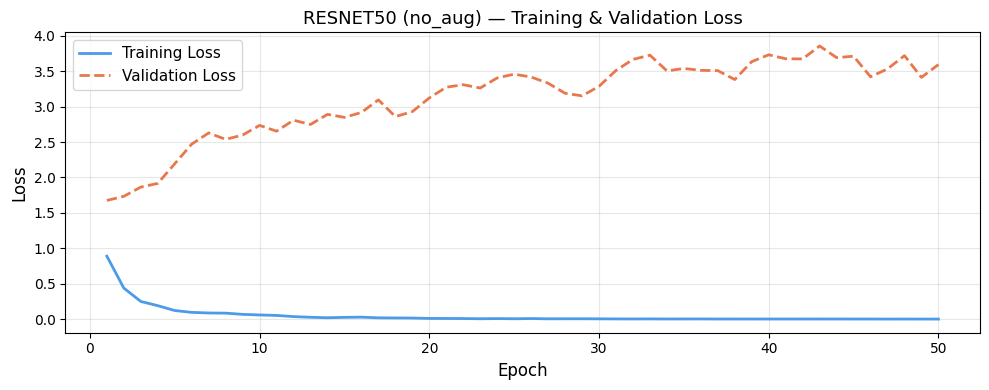

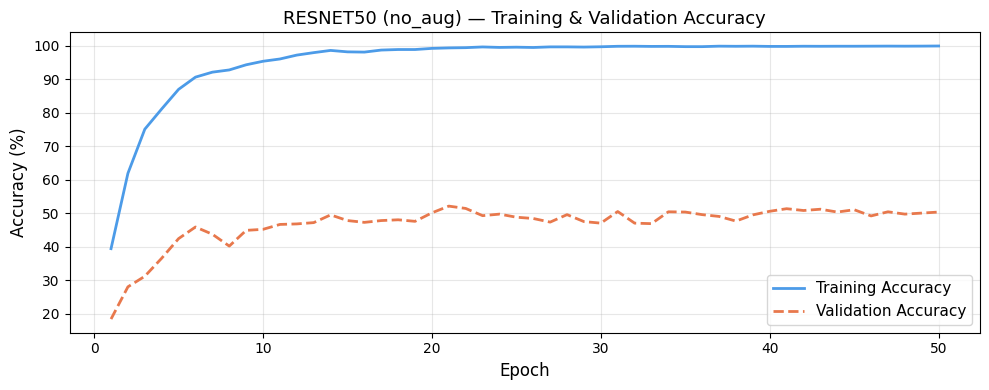

  Saved curves → /content/owmtl_kickoff/resnet50_no_aug


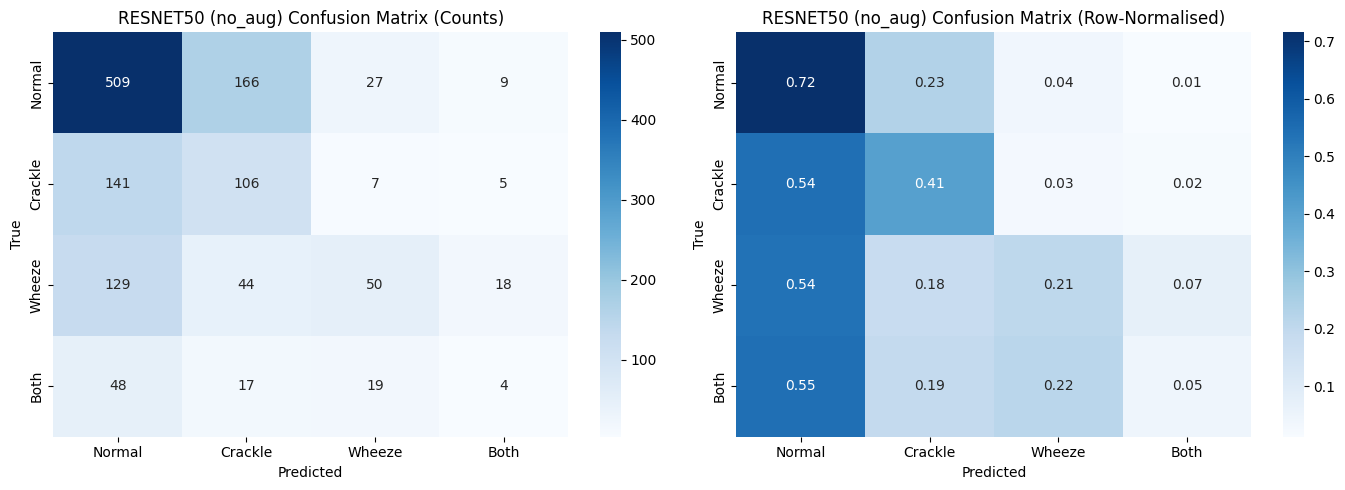

              precision    recall  f1-score   support

      Normal       0.62      0.72      0.66       711
     Crackle       0.32      0.41      0.36       259
      Wheeze       0.49      0.21      0.29       241
        Both       0.11      0.05      0.06        88

    accuracy                           0.52      1299
   macro avg       0.38      0.34      0.34      1299
weighted avg       0.50      0.52      0.49      1299


📊 ResNet-50 (no aug) metrics:
  model                    : resnet50
  setting                  : no_aug
  accuracy                 : 0.515
  precision_w              : 0.4979
  precision_m              : 0.3826
  recall_w                 : 0.515
  recall_m                 : 0.3445
  f1_weighted              : 0.492
  f1_macro                 : 0.3438
  model_size_mb            : 94.38
  total_params             : 23516228
  trainable_params         : 23516228
  total_train_time_s       : 4202.9
  avg_epoch_time_s         : 84.1


In [ ]:
train_loader, test_loader = make_loaders(augment_train=False)

rn50_model, rn50_hist, rn50_metrics, rn50_preds, rn50_labels = run_experiment(
    model_name   = "resnet50",
    model        = build_resnet50(),
    train_loader = train_loader,
    test_loader  = test_loader,
    tag          = "no_aug",
)

save_dir_rn50 = OUTPUT_DIR / "resnet50_no_aug"
plot_training_curves(rn50_hist, "resnet50", "no_aug", save_dir_rn50)
plot_confusion_matrix(rn50_labels, rn50_preds, "resnet50", "no_aug", save_dir_rn50)
print("\n📊 ResNet-50 (no aug) metrics:")
for k, v in rn50_metrics.items(): print(f"  {k:<25}: {v}")


---
## 8. Experiment 2 — EfficientNet-B2 (No Augmentation)
*(Supervisor Requirements #2, #3, #4)*

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 93.6MB/s]



  MODEL: EFFICIENTNET_B2  |  Setting: no_aug
  Ep   1/50 | TrLoss=1.0877 TrAcc=0.3299 | VaLoss=1.5985 VaAcc=0.1493 | F1=0.1070 | 80.5s
  Ep   5/50 | TrLoss=0.5994 TrAcc=0.5847 | VaLoss=1.4448 VaAcc=0.2948 | F1=0.2267 | 76.5s
  Ep  10/50 | TrLoss=0.4275 TrAcc=0.6830 | VaLoss=1.4742 VaAcc=0.3287 | F1=0.2896 | 75.4s
  Ep  15/50 | TrLoss=0.2823 TrAcc=0.7602 | VaLoss=1.5361 VaAcc=0.3626 | F1=0.3420 | 87.1s
  Ep  20/50 | TrLoss=0.2187 TrAcc=0.8121 | VaLoss=1.5650 VaAcc=0.4111 | F1=0.4080 | 84.7s
  Ep  25/50 | TrLoss=0.1756 TrAcc=0.8409 | VaLoss=1.6846 VaAcc=0.4334 | F1=0.4333 | 85.7s
  Ep  30/50 | TrLoss=0.1647 TrAcc=0.8470 | VaLoss=1.7983 VaAcc=0.4473 | F1=0.4518 | 86.2s
  Ep  35/50 | TrLoss=0.1406 TrAcc=0.8739 | VaLoss=1.8463 VaAcc=0.4565 | F1=0.4589 | 84.9s
  Ep  40/50 | TrLoss=0.1293 TrAcc=0.8752 | VaLoss=1.9088 VaAcc=0.4750 | F1=0.4766 | 83.9s
  Ep  45/50 | TrLoss=0.1324 TrAcc=0.8720 | VaLoss=1.8856 VaAcc=0.4758 | F1=0.4788 | 85.2s
  Ep  50/50 | TrLoss=0.1388 TrAcc=0.8695 | VaLoss=1.82

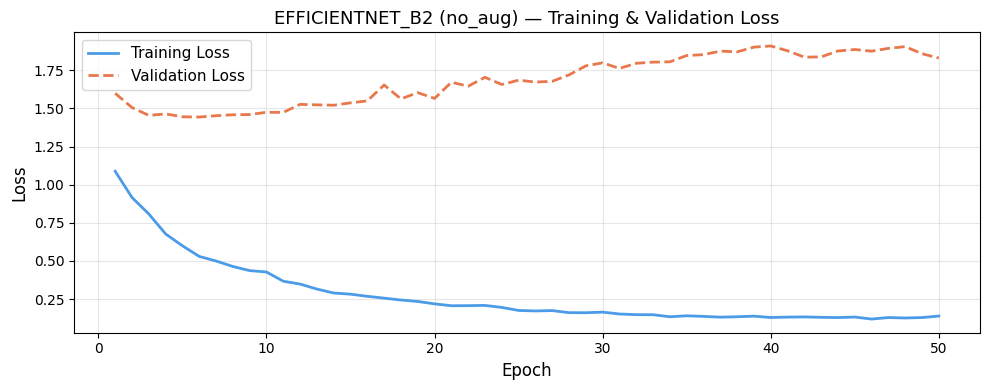

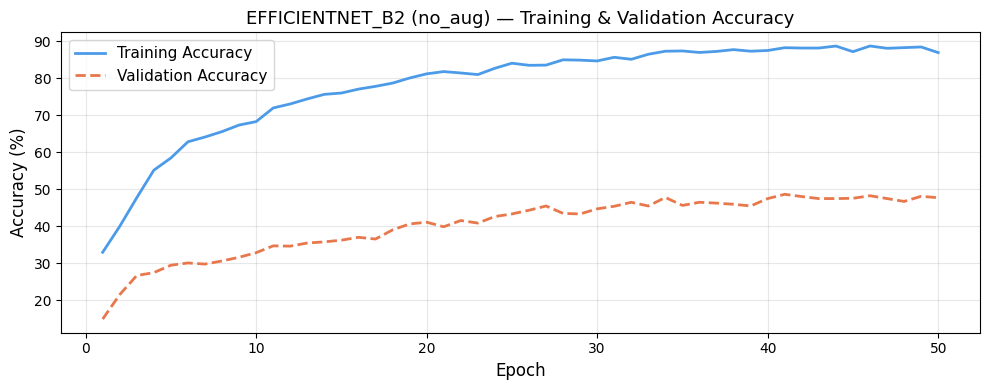

  Saved curves → /content/owmtl_kickoff/efficientnet_b2_no_aug


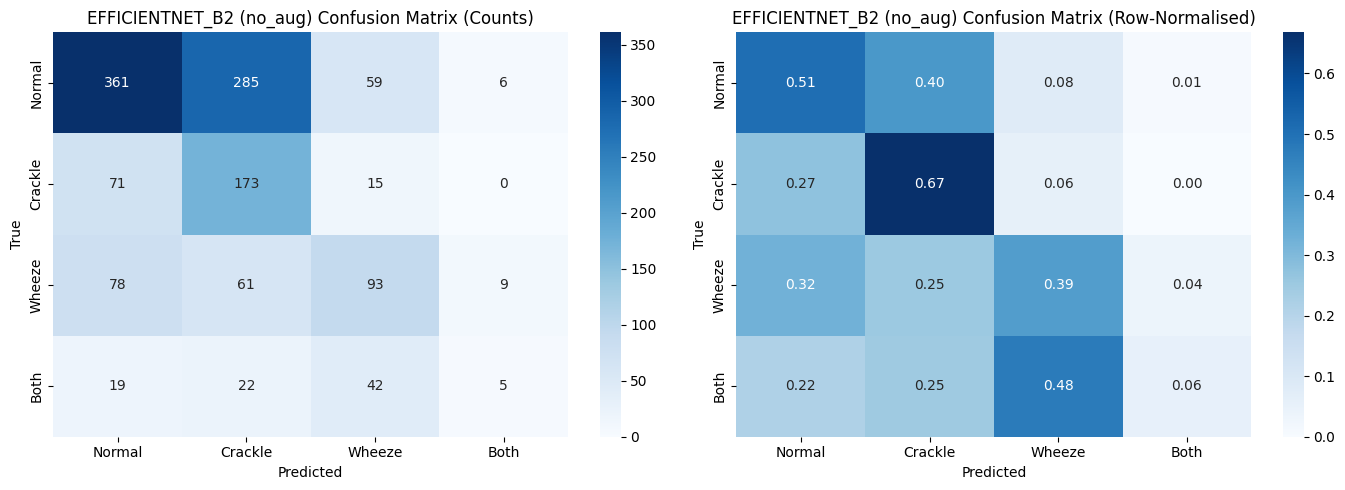

              precision    recall  f1-score   support

      Normal       0.68      0.51      0.58       711
     Crackle       0.32      0.67      0.43       259
      Wheeze       0.44      0.39      0.41       241
        Both       0.25      0.06      0.09        88

    accuracy                           0.49      1299
   macro avg       0.42      0.40      0.38      1299
weighted avg       0.54      0.49      0.49      1299


📊 EfficientNet-B2 (no aug) metrics:
  model                    : efficientnet_b2
  setting                  : no_aug
  accuracy                 : 0.4865
  precision_w              : 0.5368
  precision_m              : 0.4243
  recall_w                 : 0.4865
  recall_m                 : 0.4046
  f1_weighted              : 0.4879
  f1_macro                 : 0.3802
  model_size_mb            : 31.28
  total_params             : 7706630
  trainable_params         : 7706630
  total_train_time_s       : 4152.5
  avg_epoch_time_s         : 83.1


In [ ]:
enb2_model, enb2_hist, enb2_metrics, enb2_preds, enb2_labels = run_experiment(
    model_name   = "efficientnet_b2",
    model        = build_efficientnet_b2(),
    train_loader = train_loader,
    test_loader  = test_loader,
    tag          = "no_aug",
)

save_dir_enb2 = OUTPUT_DIR / "efficientnet_b2_no_aug"
plot_training_curves(enb2_hist, "efficientnet_b2", "no_aug", save_dir_enb2)
plot_confusion_matrix(enb2_labels, enb2_preds, "efficientnet_b2", "no_aug", save_dir_enb2)
print("\n📊 EfficientNet-B2 (no aug) metrics:")
for k, v in enb2_metrics.items(): print(f"  {k:<25}: {v}")


---
## 9. Experiment 3 — ResNet-50 (With Augmentation)
*(Supervisor Requirement #5)*

Train batches: 175 | Test batches: 41
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 228MB/s]



  MODEL: RESNET50  |  Setting: aug
  Ep   1/50 | TrLoss=1.1598 TrAcc=0.2848 | VaLoss=1.7019 VaAcc=0.1147 | F1=0.0537 | 368.2s
  Ep   5/50 | TrLoss=0.9436 TrAcc=0.4114 | VaLoss=1.5495 VaAcc=0.2248 | F1=0.1638 | 362.9s
  Ep  10/50 | TrLoss=0.8383 TrAcc=0.4840 | VaLoss=1.4514 VaAcc=0.3118 | F1=0.2958 | 365.1s
  Ep  15/50 | TrLoss=0.6579 TrAcc=0.5879 | VaLoss=1.4090 VaAcc=0.3672 | F1=0.3641 | 366.6s
  Ep  20/50 | TrLoss=0.5565 TrAcc=0.6347 | VaLoss=1.4342 VaAcc=0.3972 | F1=0.3953 | 363.5s
  Ep  25/50 | TrLoss=0.4950 TrAcc=0.6644 | VaLoss=1.4703 VaAcc=0.4257 | F1=0.4246 | 371.4s
  Ep  30/50 | TrLoss=0.4449 TrAcc=0.6944 | VaLoss=1.5377 VaAcc=0.4219 | F1=0.4157 | 361.4s
  Ep  35/50 | TrLoss=0.4106 TrAcc=0.7111 | VaLoss=1.5184 VaAcc=0.4457 | F1=0.4514 | 359.1s
  Ep  40/50 | TrLoss=0.3751 TrAcc=0.7343 | VaLoss=1.5192 VaAcc=0.4488 | F1=0.4510 | 361.7s
  Ep  45/50 | TrLoss=0.3709 TrAcc=0.7341 | VaLoss=1.4947 VaAcc=0.4573 | F1=0.4590 | 368.2s
  Ep  50/50 | TrLoss=0.3565 TrAcc=0.7429 | VaLoss=1.52

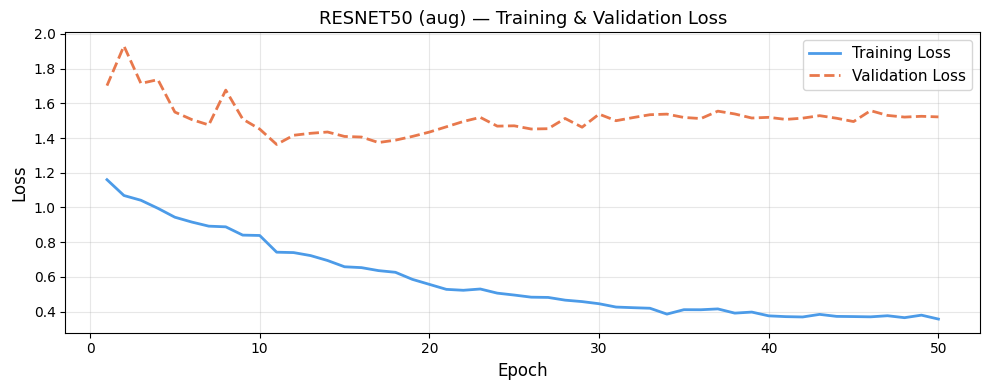

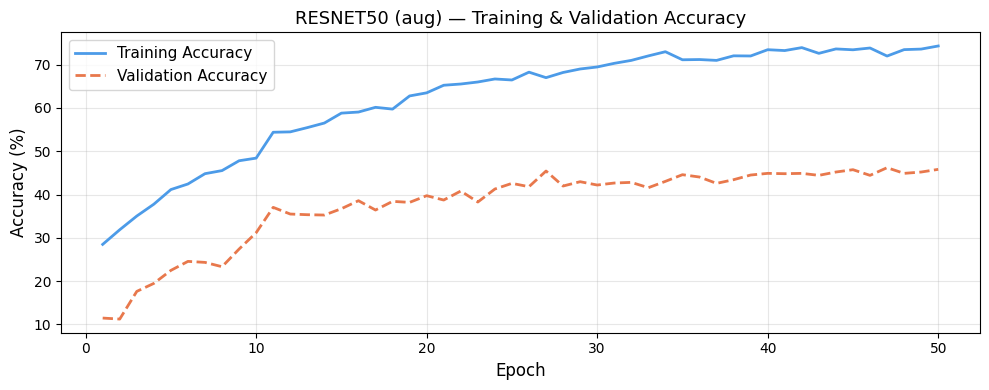

  Saved curves → /content/owmtl_kickoff/resnet50_aug


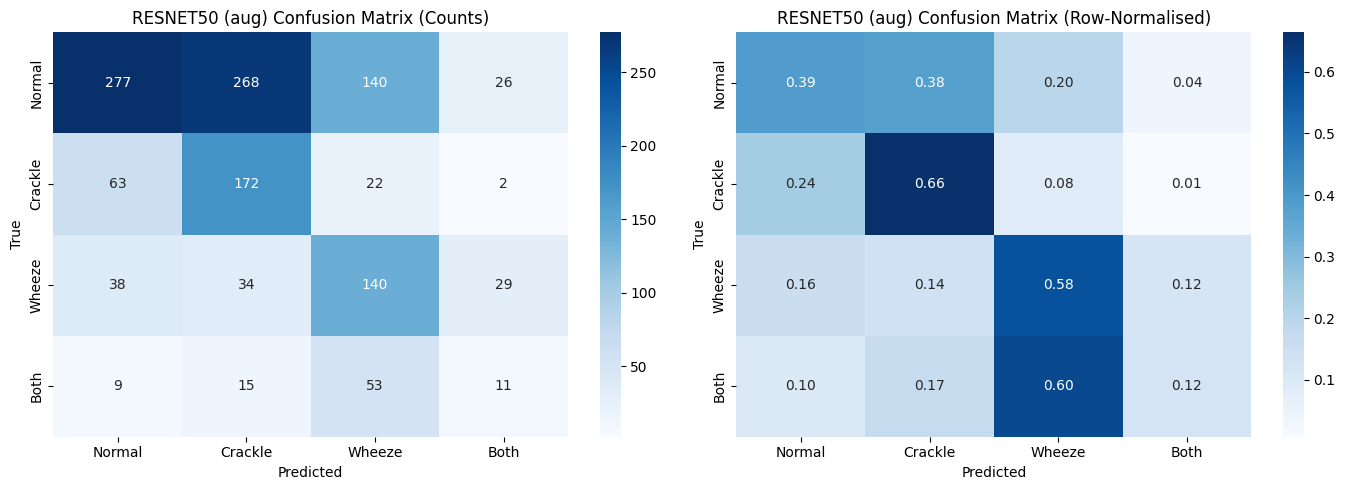

              precision    recall  f1-score   support

      Normal       0.72      0.39      0.50       711
     Crackle       0.35      0.66      0.46       259
      Wheeze       0.39      0.58      0.47       241
        Both       0.16      0.12      0.14        88

    accuracy                           0.46      1299
   macro avg       0.41      0.44      0.39      1299
weighted avg       0.55      0.46      0.46      1299


📊 ResNet-50 (aug) metrics:
  model                    : resnet50
  setting                  : aug
  accuracy                 : 0.4619
  precision_w              : 0.546
  precision_m              : 0.4059
  recall_w                 : 0.4619
  recall_m                 : 0.4399
  f1_weighted              : 0.4646
  f1_macro                 : 0.3938
  model_size_mb            : 94.38
  total_params             : 23516228
  trainable_params         : 23516228
  total_train_time_s       : 18206.6
  avg_epoch_time_s         : 364.1


In [ ]:
train_loader_aug, test_loader = make_loaders(augment_train=True)

rn50_aug_model, rn50_aug_hist, rn50_aug_metrics, rn50_aug_preds, rn50_aug_labels = run_experiment(
    model_name   = "resnet50",
    model        = build_resnet50(),
    train_loader = train_loader_aug,
    test_loader  = test_loader,          # test set never augmented
    tag          = "aug",
)

save_dir_rn50_aug = OUTPUT_DIR / "resnet50_aug"
plot_training_curves(rn50_aug_hist, "resnet50", "aug", save_dir_rn50_aug)
plot_confusion_matrix(rn50_aug_labels, rn50_aug_preds, "resnet50", "aug", save_dir_rn50_aug)
print("\n📊 ResNet-50 (aug) metrics:")
for k, v in rn50_aug_metrics.items(): print(f"  {k:<25}: {v}")


---
## 10. Experiment 4 — EfficientNet-B2 (With Augmentation)
*(Supervisor Requirement #5)*

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted at /content/drive
Checkpoint directory (Drive): /content/drive/MyDrive/CSE465_checkpoints/efficientnet_b2_aug
Resume detected — latest checkpoint: epoch 46 / 50
Train batches: 175 | Test batches: 41

  MODEL: EFFICIENTNET_B2  |  Setting: aug
  Checkpoint directory: /content/drive/MyDrive/CSE465_checkpoints/efficientnet_b2_aug
  [resume] Loading checkpoint: epoch_046.pt
  [resume] Resuming from epoch 46 → starting at epoch 47  (phase=2)
    [ckpt] Saved → epoch_047.pt
    [ckpt] Saved → epoch_048.pt
    [ckpt] Saved → epoch_049.pt
  Ep  50/50 | TrLoss=0.6185 TrAcc=0.6054 | VaLoss=1.3779 VaAcc=0.3926 | F1=0.3784 | 393.4s
    [ckpt] Saved → epoch_050.pt


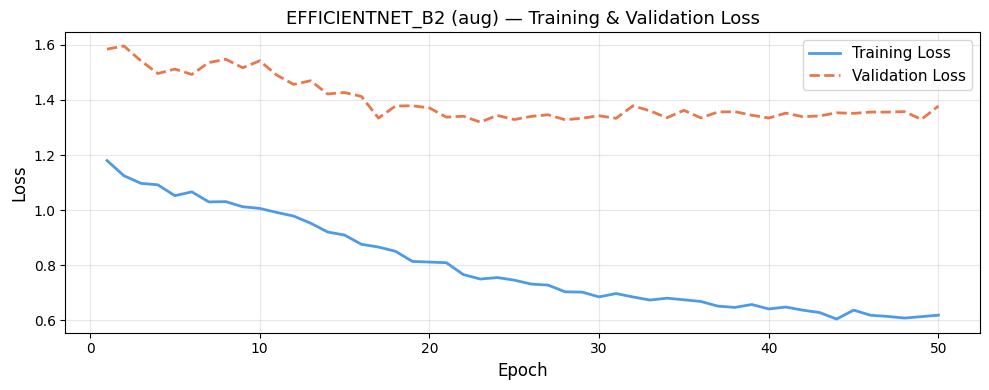

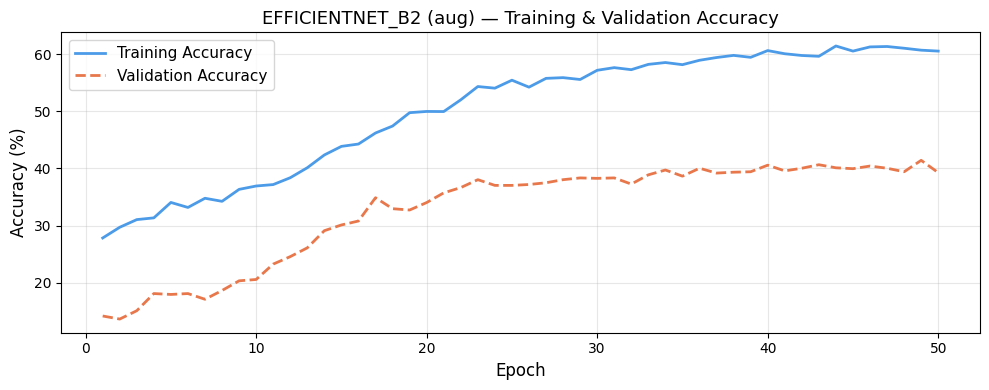

  Saved curves → /content/owmtl_kickoff/efficientnet_b2_aug


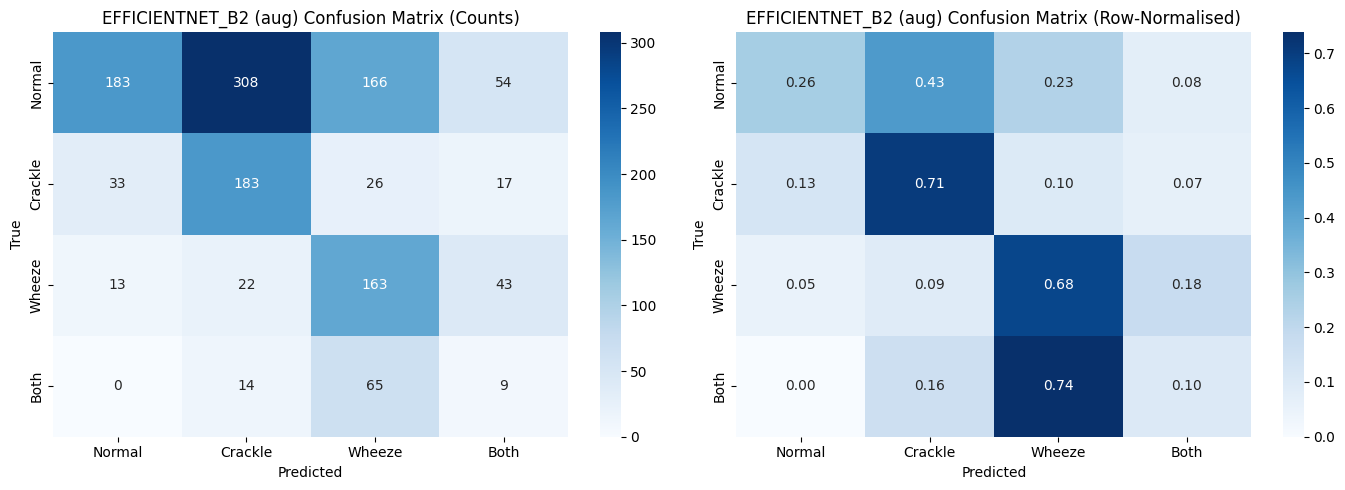

              precision    recall  f1-score   support

      Normal       0.80      0.26      0.39       711
     Crackle       0.35      0.71      0.47       259
      Wheeze       0.39      0.68      0.49       241
        Both       0.07      0.10      0.09        88

    accuracy                           0.41      1299
   macro avg       0.40      0.44      0.36      1299
weighted avg       0.58      0.41      0.40      1299


 EfficientNet-B2 (aug) metrics:
  model                    : efficientnet_b2
  setting                  : aug
  accuracy                 : 0.4142
  precision_w              : 0.5836
  precision_m              : 0.4019
  recall_w                 : 0.4142
  recall_m                 : 0.4356
  f1_weighted              : 0.4032
  f1_macro                 : 0.3584
  model_size_mb            : 31.28
  total_params             : 7706630
  trainable_params         : 7706630
  total_train_time_s       : 19264.0
  avg_epoch_time_s         : 385.3


In [22]:
# ============================================================
# EfficientNet-B2 | augmented  --  resilient (checkpoint / resume)
# ============================================================

# -- Step 1 : Mount Google Drive (persists checkpoints across sessions) --------
try:
    from google.colab import drive as _gd
    _gd.mount('/content/drive', force_remount=False)
    DRIVE_OK = True
    print('Drive mounted at /content/drive')
except Exception as _e:
    DRIVE_OK = False
    print(f'Drive mount skipped ({_e}). Checkpoints saved to /content/ only.')

# -- Step 2 : Define checkpoint path ------------------------------------------
# Change DRIVE_CKPT_BASE to your own Drive folder if desired.
DRIVE_CKPT_BASE = Path('/content/drive/MyDrive/CSE465_checkpoints')
LOCAL_CKPT_BASE = OUTPUT_DIR / 'checkpoints'

if DRIVE_OK:
    ENB2_AUG_CKPT_DIR = DRIVE_CKPT_BASE / 'efficientnet_b2_aug'
    ENB2_AUG_CKPT_DIR.mkdir(parents=True, exist_ok=True)
    print(f'Checkpoint directory (Drive): {ENB2_AUG_CKPT_DIR}')
else:
    ENB2_AUG_CKPT_DIR = LOCAL_CKPT_BASE / 'efficientnet_b2_aug'
    ENB2_AUG_CKPT_DIR.mkdir(parents=True, exist_ok=True)
    print(f'Checkpoint directory (local): {ENB2_AUG_CKPT_DIR}')

# -- Step 3 : Check if we are resuming ----------------------------------------
_existing = sorted(ENB2_AUG_CKPT_DIR.glob('epoch_*.pt'))
if _existing:
    _latest_ep = int(_existing[-1].stem.split('_')[1])
    print(f'Resume detected — latest checkpoint: epoch {_latest_ep} / {EPOCHS}')
    if _latest_ep >= EPOCHS:
        print('   Training already complete. Skipping training loop.')
else:
    print(f'No checkpoint found — starting fresh (EPOCHS={EPOCHS}).')

# -- Step 4 : Run experiment (automatically resumes if checkpoint exists) ------
train_loader_aug, test_loader = make_loaders(augment_train=True)
enb2_aug_model, enb2_aug_hist, enb2_aug_metrics, enb2_aug_preds, enb2_aug_labels = run_experiment(
    model_name     = 'efficientnet_b2',
    model          = build_efficientnet_b2(),
    train_loader   = train_loader_aug,
    test_loader    = test_loader,
    tag            = 'aug',
    checkpoint_dir = ENB2_AUG_CKPT_DIR,   # Drive-backed directory
)

# -- Step 5 : Plots & metrics --------------------------------------------------
save_dir_enb2_aug = OUTPUT_DIR / 'efficientnet_b2_aug'
plot_training_curves(enb2_aug_hist, 'efficientnet_b2', 'aug', save_dir_enb2_aug)
plot_confusion_matrix(enb2_aug_labels, enb2_aug_preds, 'efficientnet_b2', 'aug', save_dir_enb2_aug)
print('\n EfficientNet-B2 (aug) metrics:')
for k, v in enb2_aug_metrics.items(): print(f'  {k:<25}: {v}')


---
## 11. Summary Comparison Table (All Models & Settings)
*(Supervisor Requirements #3 & #5)*

          model setting  accuracy  precision_w  recall_w  f1_weighted  f1_macro  model_size_mb  total_params  trainable_params  total_train_time_s  avg_epoch_time_s
       resnet50  no_aug    0.5150       0.4979    0.5150       0.4920    0.3438          94.38      23516228          23516228              4202.9              84.1
efficientnet_b2  no_aug    0.4865       0.5368    0.4865       0.4879    0.3802          31.28       7706630           7706630              4152.5              83.1
       resnet50     aug    0.4619       0.5460    0.4619       0.4646    0.3938          94.38      23516228          23516228             18206.6             364.1
efficientnet_b2     aug    0.4142       0.5836    0.4142       0.4032    0.3584          31.28       7706630           7706630             19264.0             385.3


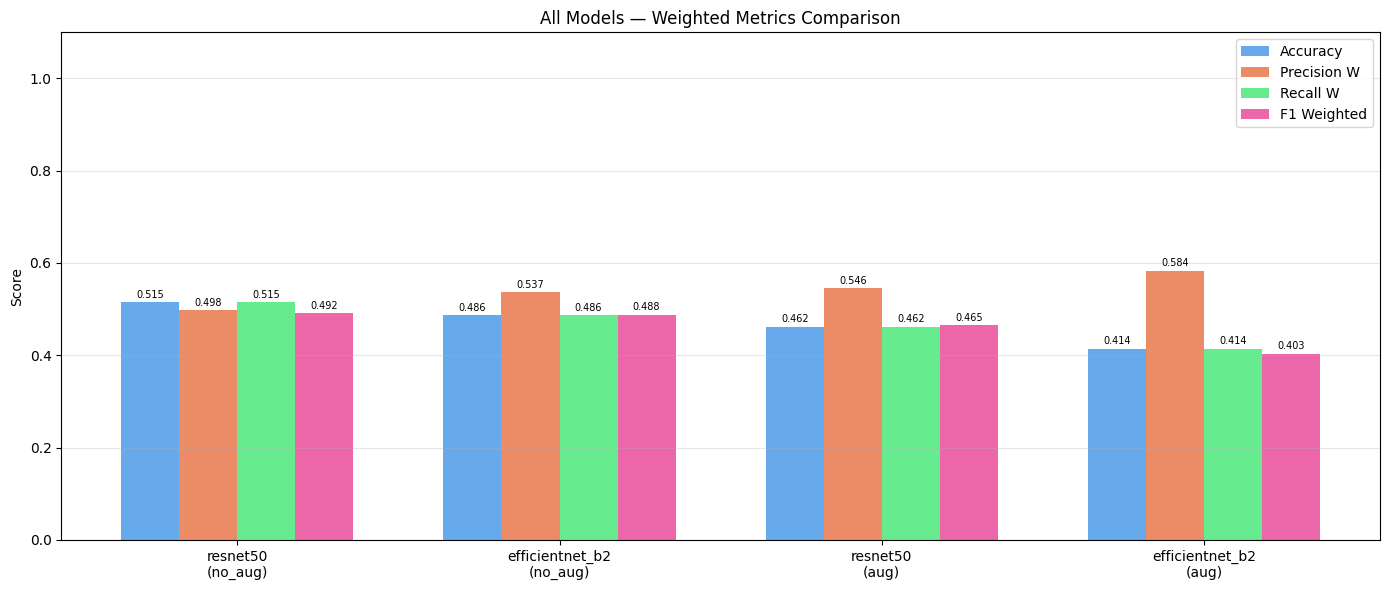


✅ Saved all_metrics_summary.csv and metrics_comparison.png


In [25]:
all_metrics = [rn50_metrics, enb2_metrics, rn50_aug_metrics, enb2_aug_metrics]
summary_df  = pd.DataFrame(all_metrics)

display_cols = [
    "model", "setting",
    "accuracy", "precision_w", "recall_w", "f1_weighted", "f1_macro",
    "model_size_mb", "total_params", "trainable_params",
    "total_train_time_s", "avg_epoch_time_s",
]
print(summary_df[display_cols].to_string(index=False))
summary_df.to_csv(OUTPUT_DIR / "all_metrics_summary.csv", index=False)

# ── Visual comparison bar chart ───────────────────────────────────────────────
metrics_to_plot = ["accuracy", "precision_w", "recall_w", "f1_weighted"]
labels_plot     = [f"{r['model']}\n({r['setting']})" for r in all_metrics]
x = np.arange(len(labels_plot))
width = 0.18
colors = ["#4C9BE8", "#E8784C", "#4CE87C", "#E84C9B"]

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    vals = [r[metric] for r in all_metrics]
    bars = ax.bar(x + i*width, vals, width, label=metric.replace("_"," ").title(),
                  color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(labels_plot, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score"); ax.set_title("All Models — Weighted Metrics Comparison")
ax.legend(loc="upper right"); ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "metrics_comparison.png", dpi=150)
plt.show()
print("\n✅ Saved all_metrics_summary.csv and metrics_comparison.png")


---
## 12. Model Architecture Summaries (# Parameters)

In [26]:
print("=" * 60)
print("ResNet-50 Architecture Summary")
print("=" * 60)
summary(build_resnet50().to(DEVICE), input_size=(1, 3, 224, 224), depth=3,
        col_names=["output_size", "num_params", "trainable"])

print("\n" + "=" * 60)
print("EfficientNet-B2 Architecture Summary")
print("=" * 60)
summary(build_efficientnet_b2().to(DEVICE), input_size=(1, 3, 224, 224), depth=3,
        col_names=["output_size", "num_params", "trainable"])


ResNet-50 Architecture Summary
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]



EfficientNet-B2 Architecture Summary


Layer (type:depth-idx)                                  Output Shape              Param #                   Trainable
EfficientNet                                            [1, 4]                    --                        True
├─Sequential: 1-1                                       [1, 1408, 7, 7]           --                        True
│    └─Conv2dNormActivation: 2-1                        [1, 32, 112, 112]         --                        True
│    │    └─Conv2d: 3-1                                 [1, 32, 112, 112]         864                       True
│    │    └─BatchNorm2d: 3-2                            [1, 32, 112, 112]         64                        True
│    │    └─SiLU: 3-3                                   [1, 32, 112, 112]         --                        --
│    └─Sequential: 2-2                                  [1, 16, 112, 112]         --                        True
│    │    └─MBConv: 3-4                                 [1, 16, 112, 112]         1,448      

---
## 13. Overlaid Loss Curves — All Experiments

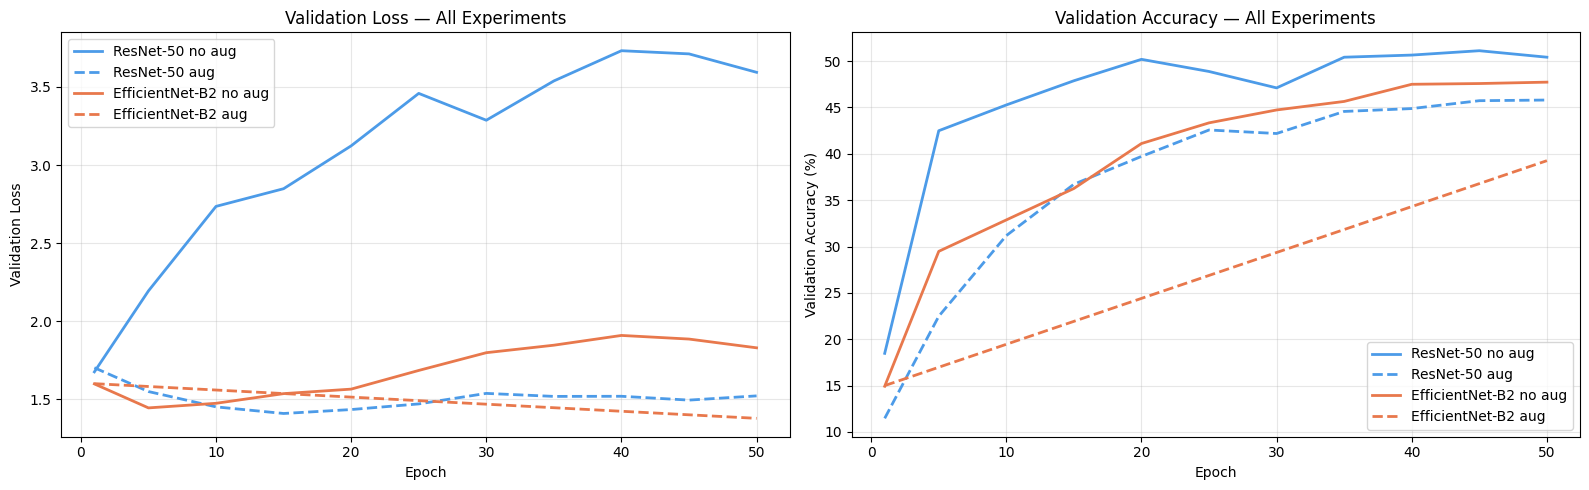

In [29]:
experiments = [
    ("ResNet-50 no aug",       rn50_hist,     "#4C9BE8", "-"),
    ("ResNet-50 aug",          rn50_aug_hist, "#4C9BE8", "--"),
    ("EfficientNet-B2 no aug", enb2_hist,     "#E8784C", "-"),
    ("EfficientNet-B2 aug",    enb2_aug_hist, "#E8784C", "--"),
]
ep = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for name, hist, color, ls in experiments:
    axes[0].plot(ep, hist["val_loss"], label=name, color=color, linestyle=ls, lw=2)
    axes[1].plot(ep, [v*100 for v in hist["val_acc"]],
                 label=name, color=color, linestyle=ls, lw=2)

for ax, ylabel, title in zip(axes,
        ["Validation Loss", "Validation Accuracy (%)"],
        ["Validation Loss — All Experiments", "Validation Accuracy — All Experiments"]):
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "all_val_curves_overlaid.png", dpi=150)
plt.show()


---
## 14. Output Files

In [30]:
print("📁 All saved outputs:")
for f in sorted(OUTPUT_DIR.rglob("*")):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f"  {str(f.relative_to(OUTPUT_DIR)):<55} {size_kb:>8.1f} KB")


Streaming output truncated to the last 5000 lines.
  npy_cycles/138_1p2_Pl_mc_AKGC417L_cycle001.npy             430.8 KB
  npy_cycles/138_1p2_Pl_mc_AKGC417L_cycle002.npy             430.8 KB
  npy_cycles/138_1p2_Pl_mc_AKGC417L_cycle003.npy             430.8 KB
  npy_cycles/138_1p2_Pl_mc_AKGC417L_cycle004.npy             430.8 KB
  npy_cycles/138_1p2_Pr_mc_AKGC417L_cycle000.npy             430.8 KB
  npy_cycles/138_1p2_Pr_mc_AKGC417L_cycle001.npy             430.8 KB
  npy_cycles/138_1p2_Pr_mc_AKGC417L_cycle002.npy             430.8 KB
  npy_cycles/138_1p2_Pr_mc_AKGC417L_cycle003.npy             430.8 KB
  npy_cycles/138_1p2_Pr_mc_AKGC417L_cycle004.npy             430.8 KB
  npy_cycles/138_1p2_Tc_mc_AKGC417L_cycle000.npy             430.8 KB
  npy_cycles/138_1p2_Tc_mc_AKGC417L_cycle001.npy             430.8 KB
  npy_cycles/138_1p2_Tc_mc_AKGC417L_cycle002.npy             430.8 KB
  npy_cycles/138_1p2_Tc_mc_AKGC417L_cycle003.npy             430.8 KB
  npy_cycles/138_1p2_Tc_mc_AKGC417L_cyc

---
## 15. Next Steps → Full OWMTL Pipeline

| Phase | What | Owner |
|---|---|---|
| Select backbone | Whichever model has highest weighted F1 here becomes the shared encoder | BB (this notebook) |
| Attach dual heads | Sound-event head + Disease-diagnosis head on top of frozen backbone | BB + Group |
| Cross-task consistency | Disagreement score between the two heads for unknown-disease detection | Pillar 2 |
| OWL staging protocol | Stage 0→1→2 with CQKD-regularised backbone | Pillar 3 |
| XAI / Uncertainty | Grad-CAM / MC-Dropout on backbone outputs | Pillar 4 |

**Backbone recommendation:** report weighted F1 from the summary table above and note which model (ResNet-50 vs EfficientNet-B2, aug vs no-aug) wins — that is the encoder to hand off to Phase 3.
